<!--Información del curso-->
<img align="left" style="padding-right:10px;" src="figuras/banner_dl.png">


<center><h1 style="font-size:2em;color:#2467C0"> Tarea
 </h1></center>


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import cv2 as cv

<div class="alert alert-success">
   
**Parte 1**
    
Utilizando 5 imágenes de películas o series (como el del ejemplo). Realizar las siguientes actividades 
    
* Para cada una de las imágenes muestre los recuadros de los rostros, ojos y sonrisas de las personas que ahí aparezcan, usando el algoritmo Haar Cascade.

* Para cada una de las imágenes muestre los recuadros de los rostros, usando RNCs.
    
</div> 

In [3]:
def haarcascade(img_path: str, param_rostros: tuple, param_ojos: tuple, param_sonrisas: tuple):
    img = cv.imread(img_path)
    img= cv.cvtColor(img, cv.COLOR_BGR2RGB)
    img_gris = cv.cvtColor(img, cv.COLOR_RGB2GRAY)
    
    detector_rostros =  cv.CascadeClassifier('datos/haarcascade_frontalface_default.xml')
    rostros = detector_rostros.detectMultiScale(img_gris, scaleFactor=param_rostros[0], minNeighbors=param_rostros[1])
    detector_ojos = cv.CascadeClassifier('datos/haarcascade_eye.xml')
    ojos = detector_ojos.detectMultiScale(img_gris, scaleFactor=param_ojos[0], minNeighbors=param_ojos[1])
    detector_sonrisas = cv.CascadeClassifier('datos/haarcascade_smile.xml')
    sonrisas = detector_sonrisas.detectMultiScale(img_gris, scaleFactor=param_sonrisas[0], minNeighbors=param_sonrisas[1])
    
    for (x,y,ancho,largo) in rostros:
        cv.rectangle(img,(x,y),(x+ancho,y+largo),color=(0,0,255),thickness=8)
        for (x_s,y_s,ancho_s,largo_s) in ojos:
            if x_s > x and x_s < x + ancho and y_s > y and y_s < y + largo:
                cv.rectangle(img,(x_s,y_s),(x_s+ancho_s,y_s+largo_s),
                            color=(255,255,255),thickness=10)
        for (x_s,y_s,ancho_s,largo_s) in sonrisas:
            if x_s > x and x_s < x + ancho and y_s > y and y_s < y + largo:
                cv.rectangle(img,(x_s,y_s),(x_s+ancho_s,y_s+largo_s),
                            color=(0,255,0),thickness=10)
    plt.imshow(img)
    plt.show()

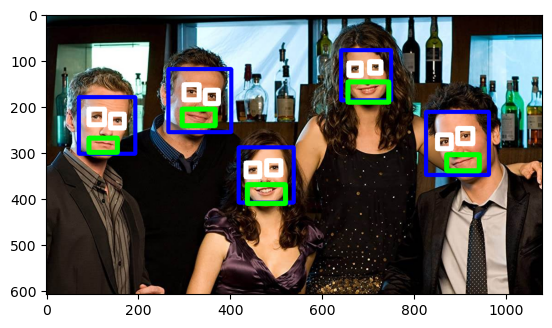

In [4]:
haarcascade(img_path='figuras/himym.jpg', param_rostros=(1.05, 20), param_ojos=(1.01, 20), param_sonrisas=(1.05, 30))

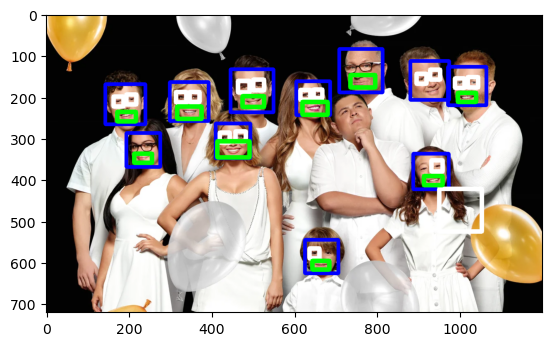

In [5]:
haarcascade(img_path='figuras/modernfamily.png', param_rostros=(1.1, 20), param_ojos=(1.02, 20), param_sonrisas=(1.2, 30))

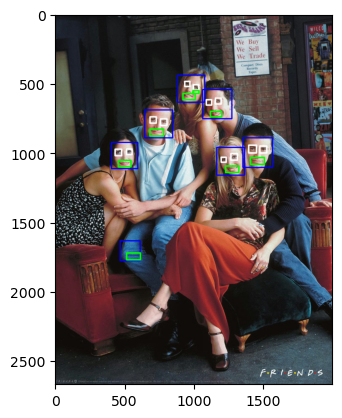

In [6]:
haarcascade(img_path='figuras/friends.png', param_rostros=(1.077, 20), param_ojos=(1.1, 20), param_sonrisas=(1.2, 15))

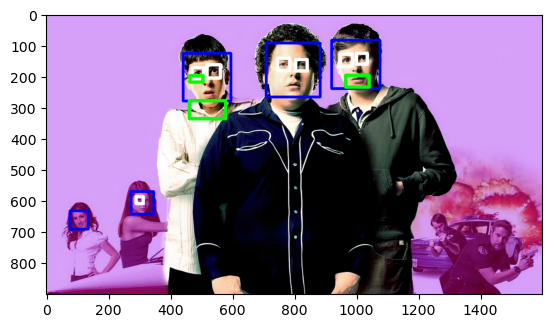

In [7]:
haarcascade(img_path='figuras/superbad.png', param_rostros=(1.077, 20), param_ojos=(1.05, 20), param_sonrisas=(1.06, 17))

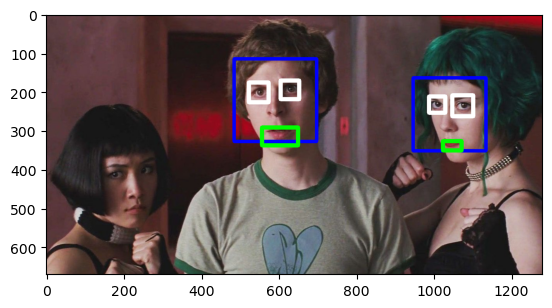

In [8]:
haarcascade(img_path='figuras/scott.png', param_rostros=(1.1, 20), param_ojos=(1.01, 15), param_sonrisas=(1.01, 35))

In [9]:
def RNC_rostros(img_path):
    pb = "datos/opencv_face_detector_uint8.pb"
    pbtxt = "datos/opencv_face_detector.pbtxt"
    net = cv.dnn.readNetFromTensorflow(pb, pbtxt)
    img = cv.imread(img_path)
    (h, w) = img.shape[:2]
    blob = cv.dnn.blobFromImage(cv.resize(img, (300, 300)),
                                scalefactor=1.0,
                                size=(300, 300),
                                mean=(104.0, 177.0, 123.0),
                                swapRB=False, crop=False)
    net.setInput(blob)
    detections = net.forward()
    for i in range(detections.shape[2]):
        conf = detections[0][0][i][2]
        if conf > 0.5:
            x1, y1, x2, y2 = (detections[0][0] [i] [3:7] * [w, h, w, h]).astype(int)
            cv.rectangle(img, (x1, y1), (x2, y2), (0, 0, 255), 2)
            cv.putText(img, f"{conf*100:.1f}%", (x1, y1-8),
                        cv.FONT_HERSHEY_SIMPLEX, 2, (0,0,255), 3)

    img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    plt.imshow(img_rgb)
    plt.show()

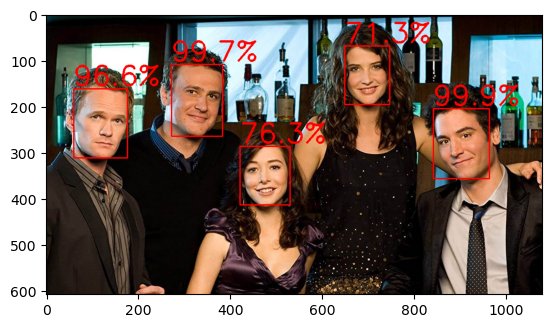

In [10]:
RNC_rostros('figuras/himym.jpg')

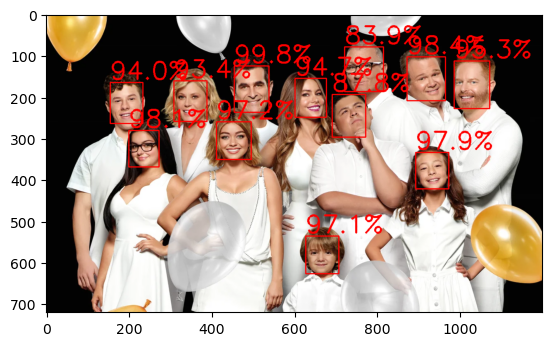

In [11]:
RNC_rostros('figuras/modernfamily.png')

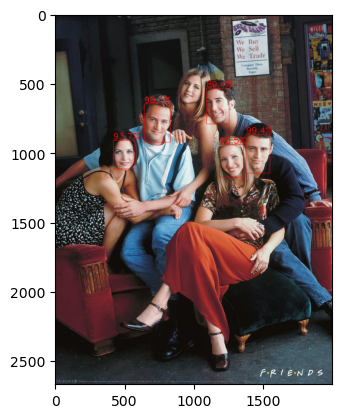

In [12]:
RNC_rostros('figuras/friends.png')

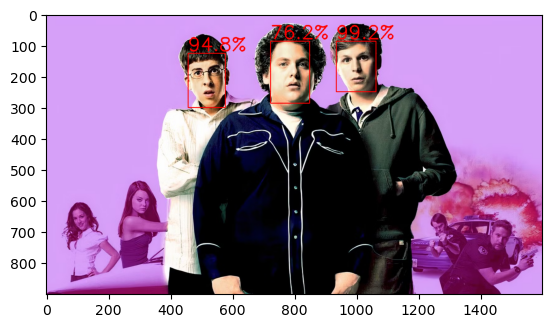

In [13]:
RNC_rostros('figuras/superbad.png')

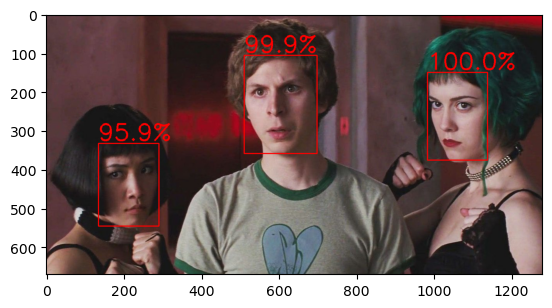

In [14]:
RNC_rostros('figuras/scott.png')

<div class="alert alert-success">
   
**Parte 2**
    
Utilizando 5 imágenes de Google Street View muestre la deteccion de los altos,  usando el algoritmo Haar Cascade. Evaluar cual de los dos archivos de deteccion funciona mejor :
    
    * stopsign_classifier.xml
    * Stopsign_HAAR_19Stages.xml.

    
</div> 

<td><img src="figuras/altos.png" align="middle" style="width:850px;"/></td>


In [15]:
from matplotlib.patches import Patch

def detector_altos(img_path:str, params: tuple):
    img = cv.imread(img_path)
    img = cv.cvtColor(img, cv.COLOR_BGR2RGB)
    img_gris = cv.cvtColor(img, cv.COLOR_RGB2GRAY)
    
    detector_1= cv.CascadeClassifier('datos/stopsign_classifier.xml')
    alto_1 = detector_1.detectMultiScale(img_gris, scaleFactor=params[0], minNeighbors=params[1])
    
    detector_2= cv.CascadeClassifier('datos/Stopsign_HAAR_19Stages.xml')
    alto_2 = detector_2.detectMultiScale(img_gris, scaleFactor=params[0], minNeighbors=params[1])
    
    for (x,y,ancho,largo) in alto_1:
        cv.rectangle(img,(x,y),(x+ancho,y+largo),color=(0,0,255),thickness=8)
    for (x,y,ancho,largo) in alto_2:
        cv.rectangle(img,(x,y),(x+ancho,y+largo),color=(255,0,0),thickness=4)
    legend_elements = [
        Patch(facecolor=(0,0,1), edgecolor='black', label='stopsign_classifier.xml'),
        Patch(facecolor=(1,0,0), edgecolor='black', label='Stopsign_HAAR_19Stages.xml')]
    
    plt.imshow(img)
    plt.legend(handles=legend_elements, loc='upper right', fontsize=10)
    plt.show()

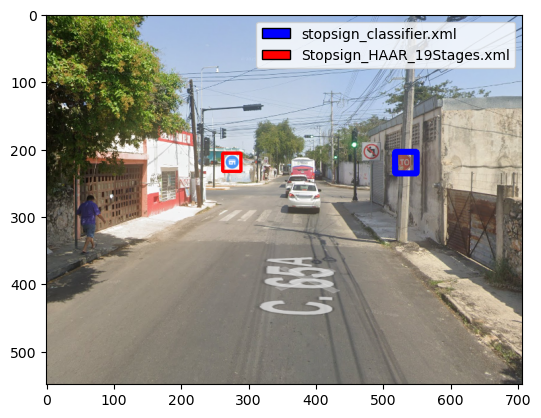

In [16]:
detector_altos('figuras/ALTO1.png', (1.005, 20))

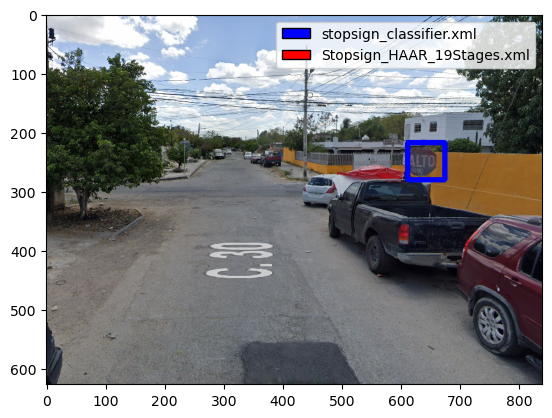

In [17]:
detector_altos('figuras/ALTO2.png', (1.01, 20))

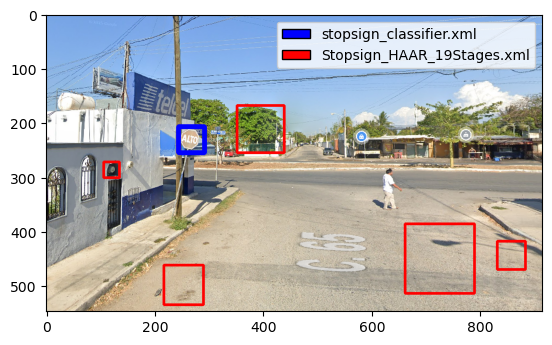

In [18]:
detector_altos('figuras/ALTO3.png', (1.0015,25))

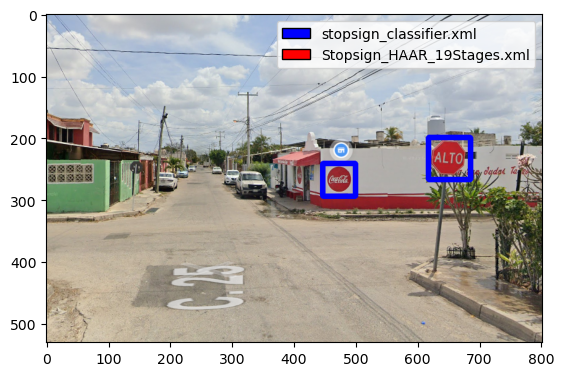

In [19]:
detector_altos('figuras/ALTO4.png', (1.05,20))

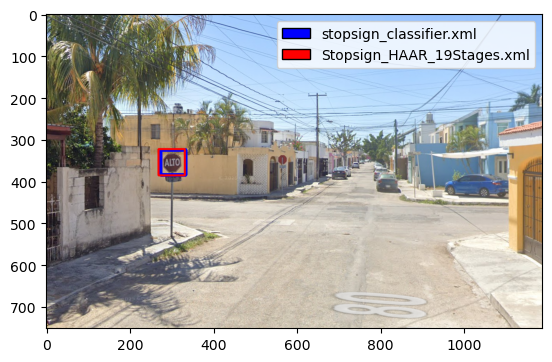

In [20]:
detector_altos('figuras/ALTO5.png', (1.05, 20))

<div class="alert alert-success">
   
**Parte 3**
    
Crear una imagen que tenga el siguiente texto

* Linea 1: Nombre y apellido
* Linea 2: Carrera y semestre
* Linea 3: Lugar de nacimiento

Utilizar pytesseract para detectar el texto
</div> 

